# ¡Hola Diego! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


----

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Diego completaste todas las tareas propuestas para el proyecto de manera sobresaliente. Demostraste un excelente manejo de las herramientas de manipulación y visualización de datos.

Como sugerencia para fortalecer aún más tu análisis estadístico, sería conveniente incorporar la prueba de Levene antes de realizar comparaciones de medias, ya que esto asegurará que tus resultados sean más robustos y confiables.

Continúa desarrollando estas habilidades, ya que serán claves en futuros proyectos.

Éxitos en tu próximo sprint 🚀

*Estado del Proyecto:* **Aprobado**

</div>

-----

## Inicialización

In [1]:
# Cargar todas las librerías necesarias para el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns
import datetime as dt

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
company_trips = pd.read_csv("/datasets/project_sql_result_01.csv")
dropoff_average = pd.read_csv("/datasets/project_sql_result_04.csv")
weather_duration = pd.read_csv("/datasets/project_sql_result_07.csv")

## Exploración general de los datos

In [3]:

# Imprime la información general/resumida sobre el Dataframe company_trips
company_trips.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [4]:
# Imprime una muestra de los datos de company_trips
print(company_trips.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299


### Observación del DataFrame company_trips: Los tipos de datos son correctos y no hay datos nulos

In [5]:
# Imprime la información general/resumida sobre el Dataframe dropoff_average
dropoff_average.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [6]:
# Imprime una muestra de los datos de company_trips
print(dropoff_average.head())

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


### Observación del DataFrame dropoff_average: Los tipos de datos son correctos y no hay datos nulos

In [7]:
# Imprime la información general/resumida sobre el Dataframe weather_duration
weather_duration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [8]:
# Imprime una muestra de los datos de weather_duration
print(weather_duration.head())

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0


### Observación del DataFrame weather_duration: Los tipos de datos no son los correctos la columna start_ts deveria ser de tipo fecha y la columna duration_seconds debería ser de tipo entero




## Corrigiendo el Dataframe weather_duration

In [9]:
# Se convierte la columna start_ts a tipo datetime
weather_duration['start_ts'] = pd.to_datetime(weather_duration['start_ts'])

# Se convierte la columna duration_seconds a tipo entero
weather_duration['duration_seconds'] = weather_duration['duration_seconds'].astype(int)

## Se verifican tipos de datos correctos del Dataframe weather_duration

In [10]:
weather_duration.info()
print()
print(weather_duration.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 25.2+ KB

             start_ts weather_conditions  duration_seconds
0 2017-11-25 16:00:00               Good              2410
1 2017-11-25 14:00:00               Good              1920
2 2017-11-25 12:00:00               Good              1543
3 2017-11-04 10:00:00               Good              2512
4 2017-11-11 07:00:00               Good              1440


### Observación: El Dataframe weather_duration ya tiene los tipos de datos correctos listo para trabajar

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Muy buen trabajo importando las librerías y los datos del proyecto. Adicionalmente usaste correctamente las funciones `info` y `head`, esto te permite hacer una primera revisión de los datos, su estructura y contenido.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo también hacer una validación de datos duplicados, con el fin de evitar errores o sesgos en en análisis de los datos

</div>
</div>

## Los 10 principales barrios en términos de finalización del recorrido

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667



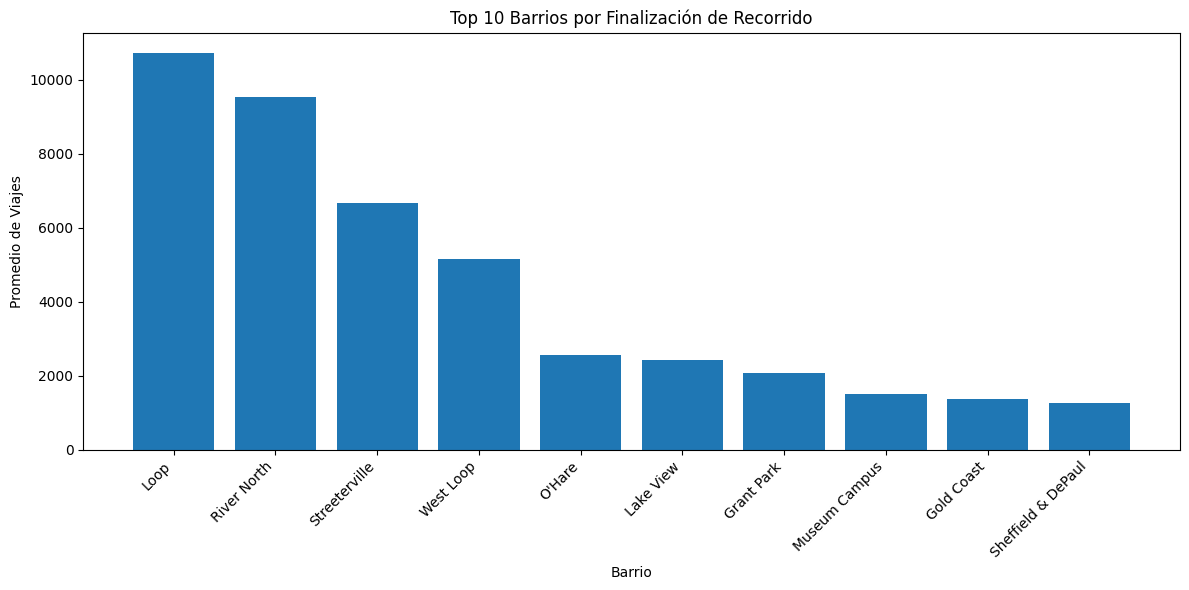

In [11]:
# Se ordena dropoff_average por promedio de viajes de forma descendente para obtener el top
dropoff_average = dropoff_average.sort_values(by='average_trips', ascending=False)
top_10_dropoff = dropoff_average.head(10)
print(top_10_dropoff)
print()
# Creamos un gráfico para mejor visualización
plt.figure(figsize=(12, 6))
plt.bar(top_10_dropoff['dropoff_location_name'], top_10_dropoff['average_trips'])
plt.title('Top 10 Barrios por Finalización de Recorrido')
plt.xlabel('Barrio')
plt.ylabel('Promedio de Viajes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Perfecto, has obtenido la gráfica para visualizar el Top de barrios relacionados con servicios de taxis

</div>

## Las 10 principales empresas de taxis por número de viajes

                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


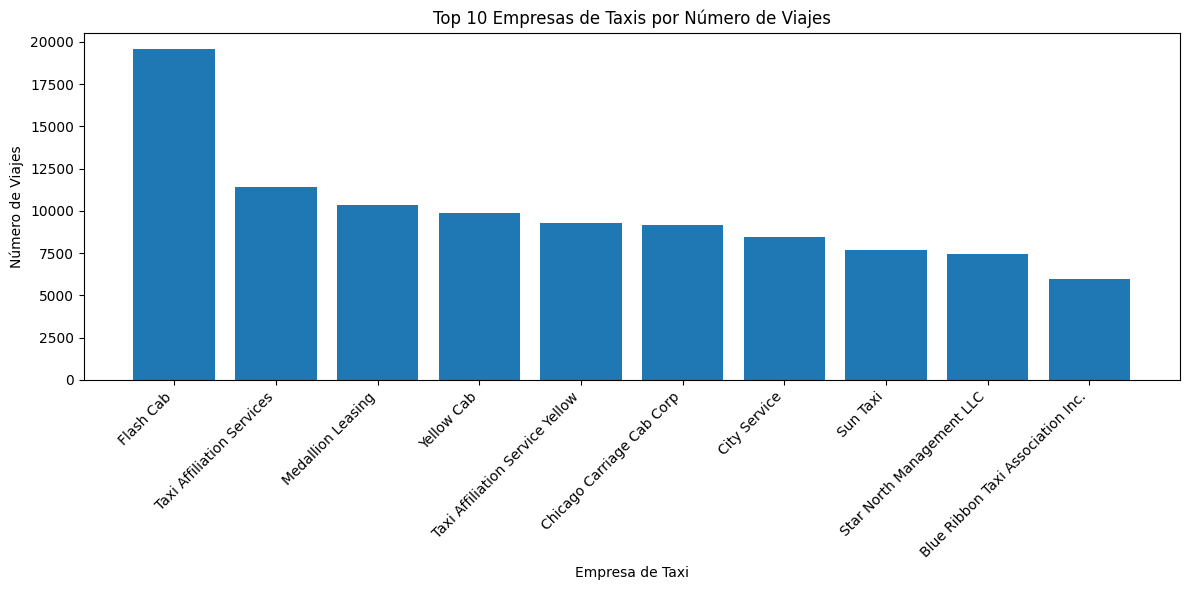

In [12]:


# Top 10 empresas por número de viajes
company_trips = company_trips.sort_values(by='trips_amount', ascending=False)
top_10_companies = company_trips.head(10)
print(top_10_companies)

# Creamos un gráfico para mejor visualización
plt.figure(figsize=(12, 6))
plt.bar(top_10_companies['company_name'], top_10_companies['trips_amount'])
plt.title('Top 10 Empresas de Taxis por Número de Viajes')
plt.xlabel('Empresa de Taxi')
plt.ylabel('Número de Viajes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Muy buen trabajo con la gráfica, se logra identificar de forma clara la distribución de viajes por compañía.

</div>


# Conclusiones paso 4:
Los datos muestran claramente que ciertas áreas concentran la mayoría de los viajes
- Loop
- River North
- Streeterville

Estas zonas son centros económicos y turísticos clave (centro financiero, restaurantes, hoteles). 
Hay una alta concentración de actividad laboral y ocio. 
Son áreas donde probablemente: Hay más tráfico mayor demanda de taxis más ingresos potenciales.

Insight: La demanda de viajes está altamente concentrada en zonas centrales y de alto movimiento económico

Alta concentración en pocas empresas
- Flash Cab
- Taxi Affiliation Services
- Medallion Leasing

Hay una clara dominancia del mercado, pocas empresas concentran gran parte de los viajes

Insight: El mercado no está completamente fragmentado, hay líderes claros.


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Buen trabajo al conectar la distribución de los viajes con el contexto urbano, entendiendo cómo ciertas zonas concentran actividad económica y turística y cómo esto influye en la demanda; además, logras relacionar esa dinámica con oportunidades potenciales dentro del servicio. También interpretas de forma acertada la estructura del mercado al identificar la presencia de actores predominantes, lo que aporta una visión más estratégica del entorno competitivo.

</div>

In [13]:
# Agregamos una nueva columna al Dataframe weather_duration para identificar el día de la semana
# (0=lunes, 6=domingo) el sabado es el 5
weather_duration['day_of_week'] = weather_duration['start_ts'].dt.weekday
print(weather_duration)

                start_ts weather_conditions  duration_seconds  day_of_week
0    2017-11-25 16:00:00               Good              2410            5
1    2017-11-25 14:00:00               Good              1920            5
2    2017-11-25 12:00:00               Good              1543            5
3    2017-11-04 10:00:00               Good              2512            5
4    2017-11-11 07:00:00               Good              1440            5
...                  ...                ...               ...          ...
1063 2017-11-25 11:00:00               Good                 0            5
1064 2017-11-11 10:00:00               Good              1318            5
1065 2017-11-11 13:00:00               Good              2100            5
1066 2017-11-11 08:00:00               Good              1380            5
1067 2017-11-04 16:00:00                Bad              2834            5

[1068 rows x 4 columns]


In [14]:
# Primero investigamos cuales son las condiciones del clima y cuales días
# de la semana hay en el dataframe weather_duration
print(weather_duration['weather_conditions'].unique())
print(weather_duration['day_of_week'].unique())

# Después calculamos las medias de de los viajes en sábado lluvioso
# y sábado soleado para darnos una idea de lo que pasará con la hipotesis
duration_saturday_bad_mean = weather_duration[weather_duration['weather_conditions']=='Bad']['duration_seconds'].mean()
duration_saturday_good_mean = weather_duration[weather_duration['weather_conditions']=='Good']['duration_seconds'].mean()

print("La media de la duración de los viajes en sábado lluvioso es:", duration_saturday_bad_mean)
print("La media de la duración de los viajes en sábado soleado es:", duration_saturday_good_mean)

#Hipótesis Nula (H₀): La duración promedio de los viajes en sabados lluviosos es igual que los sábados soleados
#Hipótesis Alternativa (H₁): La duración promedio de los viajes en sabados lluviosos es mayor que los sábados soleados

# Se realiza la prueba de hipotesis
alpha = 0.05
test_results = st.ttest_ind(weather_duration[weather_duration['weather_conditions']=='Bad']['duration_seconds'],
weather_duration[weather_duration['weather_conditions']=='Good']['duration_seconds'])

# Para prueba de una cola
p_value_one_tail = test_results.pvalue / 2

# Verificar si la media de días lluviosos es mayor
if duration_saturday_bad_mean > duration_saturday_good_mean:
    print(f"P-value para prueba de una cola: {p_value_one_tail}")
    if p_value_one_tail < alpha:
        print("Se rechaza H₀: Los viajes duran significativamente más en sábados lluviosos")
    else:
        print("No se rechaza H₀: No hay evidencia suficiente")




['Good' 'Bad']
[5]
La media de la duración de los viajes en sábado lluvioso es: 2427.2055555555557
La media de la duración de los viajes en sábado soleado es: 1999.6756756756756
P-value para prueba de una cola: 3.2589851635497367e-12
Se rechaza H₀: Los viajes duran significativamente más en sábados lluviosos


# Conclusiones paso 5:
Según la prueba de hipótesis, los días sábados lluviosos los viajes duran 7.13 minutos más que
los sábados soleados, esto es debido al tráfico que se genera en las ciudades debido a las lluvias

# CONCLUSIONES GENERALES
La demanda de servicios de taxi está fuertemente concentrada tanto geográficamente como a nivel de mercado. Por un lado, las zonas centrales de alta actividad económica y turística concentran la mayor cantidad de viajes, lo que refleja patrones de movilidad ligados al trabajo y al ocio. Por otro lado, el mercado está dominado por unas pocas empresas, lo que indica una estructura poco fragmentada con líderes bien definidos.
Además, factores externos como el clima influyen directamente en la duración de los viajes: en días lluviosos, especialmente los sábados, los tiempos de traslado aumentan significativamente debido al incremento del tráfico.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Diego aplicaste correctamente la prueba de hipótesis comparando la distribución de dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula, logrando comprobar que el clima sí afecta la duración de los viajes en Taxi

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo realizar previamente una prueba de [Levene](https://www.educaopen.com/digital-lab/blog/educacion-digital/prueba-de-levene) para evaluar la igualdad de las varianzas, lo que te permitirá configurar adecuadamente el parámetro **equal_var** en la función `ttest_ind`. Esto te brindará una interpretación más precisa de los resultados además garantizará que la *prueba t* sea estadísticamente válida.


</div>
</div>